## Test mask

Ce notebook teste la creation des masques pour detecter les section sans audio

In [1]:
#
# assure le reload de src si modifications sont faite
#
%load_ext autoreload
%autoreload 2

In [2]:
#
# import utilitaires
#
%matplotlib inline

import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import cv2 as cv

from pathlib import Path

In [3]:
#
# import package develope pour le projet
#
import ffury
from ffury.configs import (
    DatasetType,
    DEFAULT_CONFIG_FILE,
    load_config
)
from ffury.optional.development.dataset import IndexedDataset

def get_config():
    # creation config - on sait que DEFAULT_CONFIG_FILE est dans le repertoire parent
    config = Path(ffury.__file__).parents[2].joinpath(DEFAULT_CONFIG_FILE)
    return load_config(config)

config = get_config()

In [4]:
# load datasets
# dataset_train = IndexedDataset.create(config, DatasetType.TRAIN)

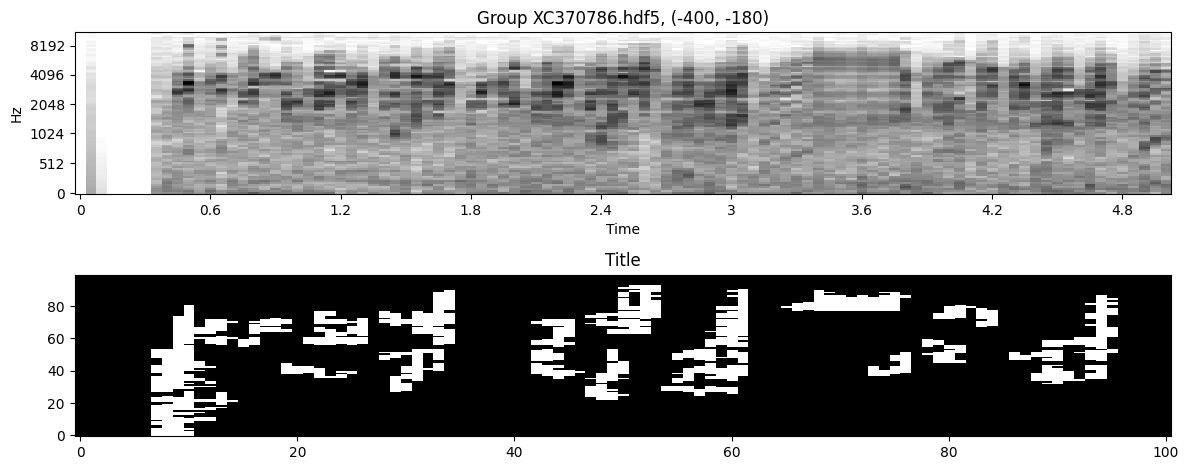

Max: 0.0
Min: -1.0


In [129]:
import librosa as rosa
from ffury.optional.development.misc.hdf5 import open_file
from ffury.optional.development.transforms.properties import _SPECTROGRAM

def specshow(data):
    if True:
        rosa.display.specshow(data,
                              x_axis='time',
                              y_axis='mel',
                              sr=config.preprocess.clip_sampling_rate_hz,
                              ax=plt.gca(),
                              n_fft=config.preprocess.spectrogram_n_ftt,
                              hop_length=config.preprocess.spectrogram_hop_length,
                              cmap="gray_r")
    else:
        plt.gca().imshow(data,
                         cmap="gray",
                         aspect="auto",
                         interpolation="nearest",
                         vmin=np.min(data),
                         vmax=np.max(data))
        plt.gca().invert_yaxis()

def mask(data):

    mask = cv.adaptiveThreshold((data * -255).astype(np.uint8),
                                255,
                                cv.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv.THRESH_BINARY_INV,
                                31,
                                15.5)
    # Z_SCALE = 0.90

    # data = np.exp(data)

    # # thresholds = np.quantile(data, q=Z_SCALE, axis=0)
    # thresholds = np.mean(data, axis=0) + 6.0 * np.std(data, axis=0)

    # cols = np.max(data, axis=0) > thresholds

    # print( np.round(np.max(data, axis=0), 3) )
    # print( np.round(thresholds, 3) )
    # print( cols )

    # mask = np.zeros_like(cols, dtype=np.uint8)
    # mask[cols] = 255

    # mask = np.repeat(mask[np.newaxis, ...], data.shape[0], axis=0)

    # print( threshold )


    # mask = np.zeros_like(data, dtype=np.uint8)
    # mask[ data >= threshold ] = 255

    # Find contours in the thresholded image
    contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    # Create an empty mask
    mask = np.zeros_like(data, dtype=np.uint8)

    # Fill contours in the mask
    for contour in contours:
        if cv.contourArea(contour) > 10:
            cv.drawContours(mask, [contour], -1, (255), thickness=cv.FILLED)

    # kernel = cv.getStructuringElement(cv.MORPH_RECT, (3, 3))
    # mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel, iterations=1)
    # mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel, iterations=1)

    return mask

def plot_group(path, start, stop):
    with open_file(path, "r") as file:
        data = file[_SPECTROGRAM][:, start:stop]

        mask_ = mask(data)

        fig = plt.figure(figsize=(12, 7))

        # plt.subplot(311)
        # plt.gca().hist(data[:, 3].flatten())
        # plt.title("Hist")

        plt.subplot(312)
        specshow(data)
        plt.title(f"Group {path.name}, ({start}, {stop})")

        plt.subplot(313)
        plt.gca().imshow(mask_,
                         cmap="gray",
                         aspect="auto",
                         interpolation="nearest",
                         vmin=0.0,
                         vmax=1.0)
        plt.gca().invert_yaxis()
        plt.title("Title")

        plt.tight_layout()
        plt.show()

        print( "Max:", np.max(data) )
        print( "Min:", np.min(data) )


# plot_group(Path.joinpath(config.paths.BUILD_DIR, _SPECTROGRAM, "barswa/XC187796.hdf5"),
#            0,
#            -1)

# plot_group(Path.joinpath(config.paths.BUILD_DIR, _SPECTROGRAM, "thrnig1/XC25663.hdf5"),
#            0,
#            -1)

plot_group(Path.joinpath(config.paths.BUILD_DIR, _SPECTROGRAM, "barswa/XC370786.hdf5"),
           -400,
           -180)